In [12]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [138]:
lake='geneva'
base_path = rf"/storage/alplakes_test/{lake}_100m_2025"
input_folder = os.path.join(base_path, "outputs_swirl", "eddy_catalogues_final")

output_folder = os.path.join(base_path, "outputs_swirl", "ke_eddy")
os.makedirs(output_folder, exist_ok=True)

In [117]:
lake_csv_path = os.path.join(input_folder, "lake_characteristics.csv")

In [118]:
df_lake = pd.read_csv(lake_csv_path)
df_lake = df_lake.set_index('id', drop=False)
df_lake['date'] = pd.to_datetime(df_lake['date'])

In [54]:
df_lake

,time_index,depth_index,date,depth_[m],surface_area_[m2],volume_slice_[m3],kinetic_energy_[MJ],mean_temperature_lake_[°C],id
id,,,,,,,,,
0,1415.0,0,2025-02-28 23:30:00,-0.250000,573400000.0,2.867000e+08,588.426493,7.090362,0
1,1415.0,1,2025-02-28 23:30:00,-0.757500,573400000.0,2.953010e+08,445.399905,7.100053,1
2,1415.0,2,2025-02-28 23:30:00,-1.280500,573400000.0,3.044754e+08,399.371041,7.106007,2
3,1415.0,3,2025-02-28 23:30:00,-1.820000,573390000.0,3.142177e+08,371.096112,7.109244,3
4,1415.0,4,2025-02-28 23:30:00,-2.376000,573390000.0,3.233920e+08,359.640537,7.111165,4
...,...,...,...,...,...,...,...,...,...
437995,10175.0,45,2026-02-28 23:30:00,-48.271500,470070000.0,9.189869e+08,307.325278,6.767951,437995
437996,10175.0,46,2026-02-28 23:30:00,-50.256500,464780000.0,9.365317e+08,313.373708,6.768641,437996
437997,10175.0,47,2026-02-28 23:30:00,-52.302502,459330000.0,9.540284e+08,319.221216,6.769564,437997


# Volume

In [ ]:
df_lake[df_lake['time_index'] == 1]['volume_slice_[m3]'].sum()

In [ ]:
df_lake['volume_slice_[m3]'].sum()

# Distance to nearest shore

In [167]:
lake='neuchatel'
base_path = rf"/storage/alplakes_test/{lake}_100m_2025"
lake_mask = np.load(os.path.join(base_path, 'grid', 'mask_lake.npy'))
resolution = 100  # meters

In [168]:
from scipy.ndimage import distance_transform_edt

In [169]:
distance_to_shore = distance_transform_edt(lake_mask[0,:,:], sampling=resolution)

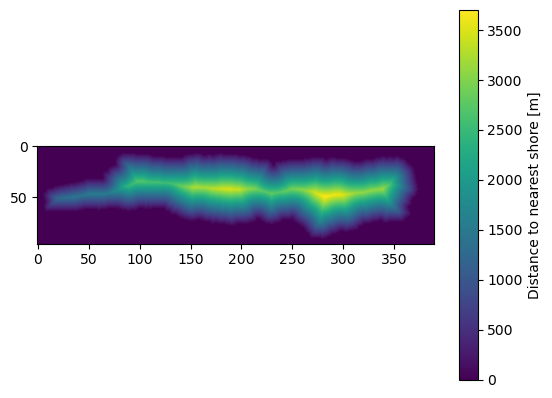

In [170]:
plt.imshow(distance_to_shore)
plt.colorbar(label='Distance to nearest shore [m]')

In [171]:
import seaborn as sns

In [172]:
distance_to_shore_flat = distance_to_shore.flatten()
distance_to_shore_flat = distance_to_shore_flat[distance_to_shore_flat > 0]  # Exclude zero values (land)

Text(0.5, 1.0, 'Neuchatel')

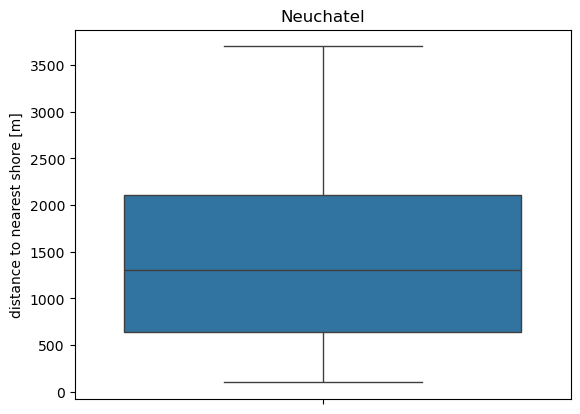

In [173]:
sns.boxplot(y=distance_to_shore_flat, showfliers=False)
plt.ylabel("distance to nearest shore [m]")
plt.title(f"{lake.capitalize()}")

<Axes: ylabel='Count'>

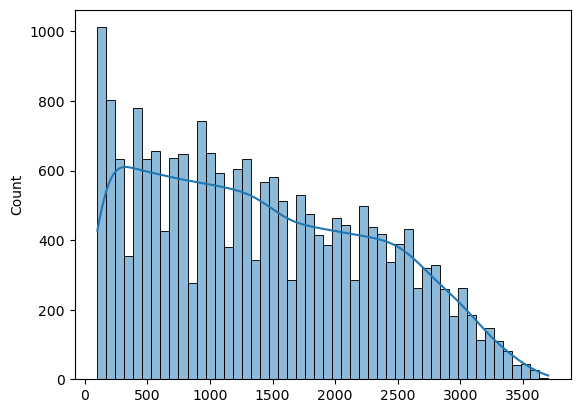

In [174]:
sns.histplot(distance_to_shore_flat, bins=50, kde=True)

In [175]:
# Compute statistics
mean_d = np.mean(distance_to_shore_flat)
std_d = np.std(distance_to_shore_flat)

# Coefficient of variation
cv = std_d / mean_d

print(f"Lake: {lake.capitalize()}")
print(f"Mean distance: {mean_d:.3f}")
print(f"Median distance: {np.median(distance_to_shore_flat):.3f}")
print(f"Std distance: {std_d:.3f}")
print(f"Coefficient of variation: {cv:.3f}")

Lake: Neuchatel
Mean distance: 1417.478
Median distance: 1303.840
Std distance: 889.981
Coefficient of variation: 0.628
